
## How to Use the Notebooks

To run these notebooks, follow these steps:


### 1. Install **`gdal`** Package
Installing `gdal` via `pip` may fail. Therefore, we recommend using conda to install it:
```bash
conda install gdal -c conda-forge
```

### 2. Install **`polsartools`** Package

Before running the notebooks, you'll need to install the core **`polsartools`** package. 

**Option A:** Install from PyPI `pip` (stable release)

```bash
pip install polsartools
```

**Option B:** Install from conda (stable release)

```bash
conda install polsartools -c bnarayanarao
```


**Option C:**  Install the latest version from GitHub (if you need recent updates or fixes)

```bash
pip install git+https://github.com/Narayana-Rao/polsartools.git#egg=polsartools
```
> **Note:** If you encounter a `"module not found"` error or require newer features, prefer the [GitHub installation](https://github.com/Narayana-Rao/polsartools).

### 3. Verify the Installation

After successfully installing `polsartools`, you can verify it by importing the package:

```bash
import polsartools as pst
```

If this runs without errors, you're ready to explore and run the notebooks.




In [1]:
import polsartools as pst
import os
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np


In [2]:

def read_rst(file):
    ds = gdal.Open(file)
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray()
    arr[arr==0] = np.nan
    return arr


def plot_images(*filenames, lower_percentile=2, upper_percentile=98, max_cols=4):
    # Function to compute vmin and vmax based on nanpercentiles
    def compute_vmin_vmax(data):
        data_no_nan = data[np.isfinite(data)]  # Remove NaNs
        vmin = np.percentile(data_no_nan, lower_percentile)
        vmax = np.percentile(data_no_nan, upper_percentile)
        return vmin, vmax
    
    # Number of images to plot
    num_images = len(filenames)

    # Calculate the number of rows and columns
    ncols = min(max_cols, num_images)  # Use max_cols but limit it to num_images
    nrows = np.ceil(num_images / ncols).astype(int)  # Calculate number of rows

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = axes.flatten() 

    for i, filename in enumerate(filenames):
        data = read_rst(filename)  # Load the data from the file
        vmin, vmax = compute_vmin_vmax(data)
        ax = axes[i]
        im = ax.imshow(data, vmin=vmin, vmax=vmax)
        ax.set_title(os.path.basename(filename))
        fig.colorbar(im, ax=ax)

    # Turn off any unused axes
    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    # Adjust layout
    plt.tight_layout()
    plt.show()

#### 1. Extract multilooked C3 matrix elements

The sample dataset used in this tutorial can be downloaded from the following URL

https://ietr-lab.univ-rennes1.fr/polsarpro-bio/san-francisco/dataset/SAN_FRANCISCO_ALOS2.zip



In [3]:
# Provide path to the extracted folder
dataFolder = r"../data/ALOS2_QP"

#The following function extracts single-look S2 or multilooked C4/C3/T4/T3 matrix from ALOS-2 HBQ FP data

pst.import_alos2_hbq_l11(dataFolder,mat='C3',azlks=8,rglks=4, 
                  fmt='tif', # output format tif//bin
                  cog=False, ovr=[2, 4, 8, 16], # COG prameters
                  comp=False, # Tiff compression (optional)
                  out_dir=None, # output path to save the extracted matrix (default is input directory)
                  recip=False, # Scatterin reciprocity for S2, C4/T4 matrices 
                 )


Progress: 100%|███████████████████████████████████████████████████████████| 720/720 [00:16<00:00, 44.89block/s]


Saved file ../data/ALOS2_QP/C3/C11.tif
Saved file ../data/ALOS2_QP/C3/C12_real.tif
Saved file ../data/ALOS2_QP/C3/C12_imag.tif
Saved file ../data/ALOS2_QP/C3/C13_real.tif
Saved file ../data/ALOS2_QP/C3/C13_imag.tif
Saved file ../data/ALOS2_QP/C3/C22.tif
Saved file ../data/ALOS2_QP/C3/C23_real.tif
Saved file ../data/ALOS2_QP/C3/C23_imag.tif
Saved file ../data/ALOS2_QP/C3/C33.tif
Execution time for convert_S: 16.00 seconds
Execution time for import_alos2_hbq_l11: 56.00 seconds


#### 2. Speckle filtering using polarimetric refined-Lee filter (optional)

In [4]:
"""
The following function generates speckle filtered polarimetric matrices using the refined lee polarimetric speckle filter: 
        
input C3/T3/C2/T2 folder path, window_size between 3-31  

"""

C3Folder = os.path.join(dataFolder,'C3')
window_size = 3
pst.filter_refined_lee(C3Folder,win=window_size,
                  fmt='tif', # output format tif//bin
                  sub_dir=True, # creates a sub directory with filtered data
                  cog=False, ovr=[2, 4, 8, 16], # COG prameters
                  comp=False, # Tiff compression (optional)
        )

Progress: 100%|█████████████████████████████████████████████████████████████| 24/24 [00:02<00:00, 10.36block/s]


Saved file ../data/ALOS2_QP/rlee_3x3/C3/C11.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/C12_real.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/C12_imag.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/C13_real.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/C13_imag.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/C22.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/C23_real.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/C23_imag.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/C33.tif
Execution time for filter_refined_lee: 2.00 seconds


#### 3. Generate a quick look Pauli RGB from C3/T3 matrix (optional)

Pauli RGB image saved as ../data/ALOS2_QP/rlee_3x3/C3/PauliRGB.png
Execution time for pauli_rgb: 2.00 seconds


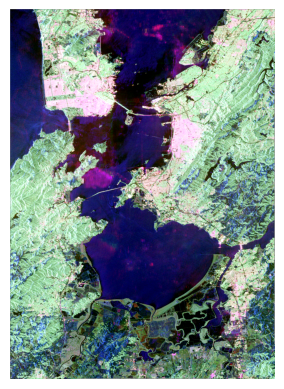

In [5]:
# # update the C3 folder based on your folder
C3Folder = os.path.join(dataFolder,'rlee_3x3','C3')

pst.pauli_rgb(C3Folder)

#### 4. Generating Decomposition parameters

#### 4.1. Generate H/A/α Decomposition parameters

Progress: 100%|█████████████████████████████████████████████████████████████| 24/24 [00:03<00:00,  7.49block/s]


Saved file ../data/ALOS2_QP/rlee_3x3/C3/H_fp.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/alpha_fp.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/anisotropy_fp.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/e1_norm.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/e2_norm.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/e3_norm.tif
Execution time for h_a_alpha_fp: 3.00 seconds


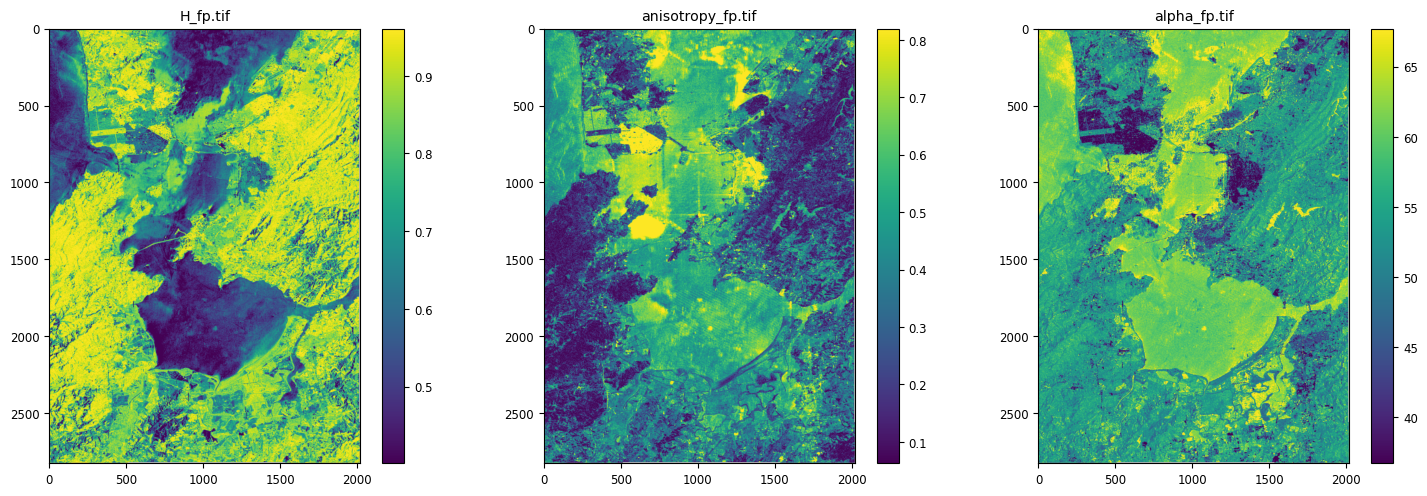

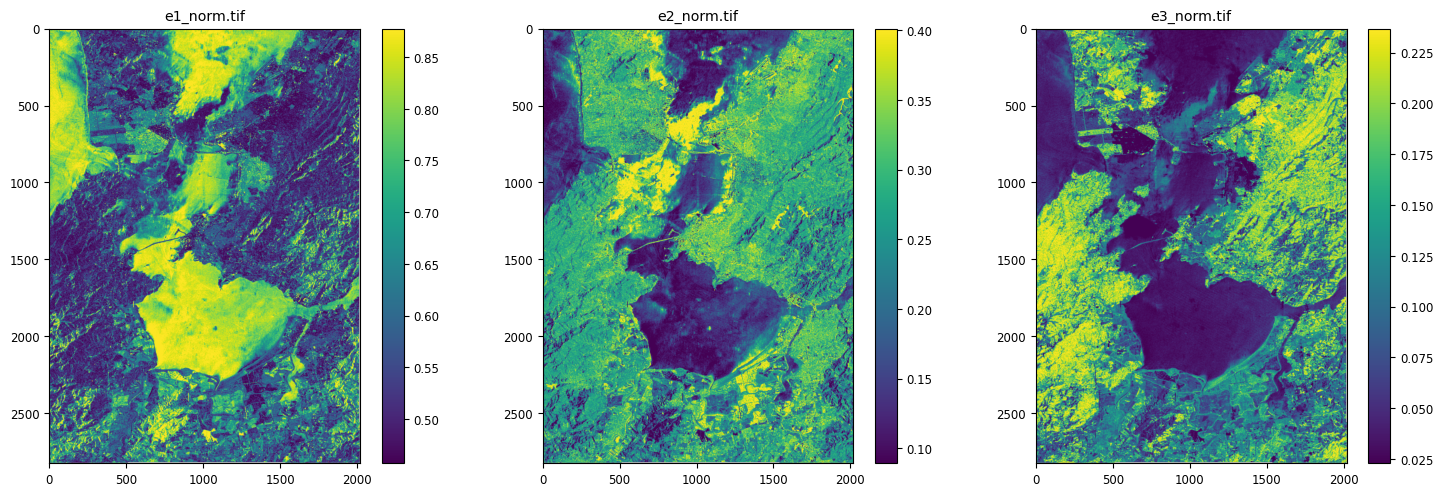

In [6]:

"""
The following function generates H/A/alpha decomposition paramters: 
        Alpha, entropy, anisotropy and,
        normalized eigen values e1_norm, e2_norm, e3_norm in geotif format

input C3/T3 folder path, window_size is optional  

"""

pst.h_a_alpha_fp(C3Folder,win=3) 


### Plotting
plot_images(os.path.join(C3Folder,'H_fp.tif'),
             os.path.join(C3Folder,'anisotropy_fp.tif'),
              os.path.join(C3Folder,'alpha_fp.tif'))

plot_images(os.path.join(C3Folder,'e1_norm.tif'),
             os.path.join(C3Folder,'e2_norm.tif'),
             os.path.join(C3Folder,'e3_norm.tif'))




#### Plot Entropy-Alpha 2D plane

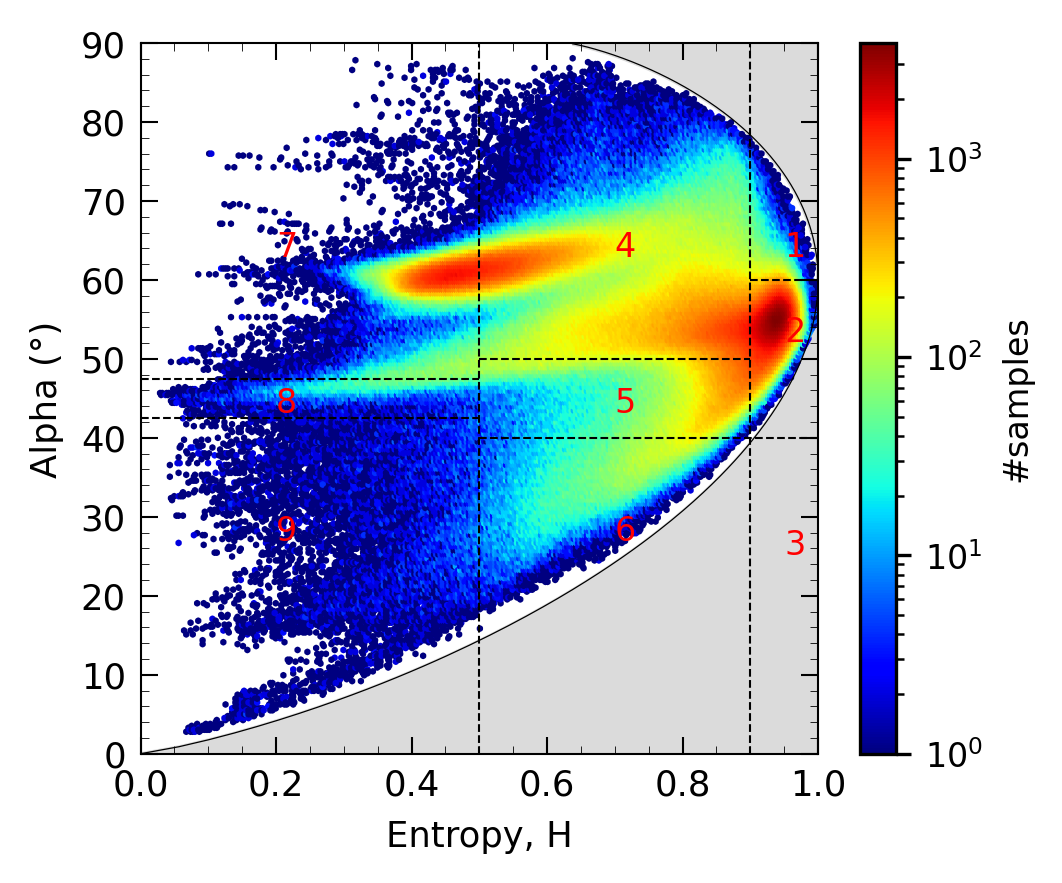

In [7]:
hFile = C3Folder + '/H_fp.tif'
aFile = C3Folder + '/alpha_fp.tif'

pst.plot_h_alpha_fp(hFile,aFile,cmap='jet',
                    norm='log',
                   # ppath = '',# give a name.png to save the plot as png 
                  zone_lines=True,
                  # zone_ids=False,
                   )

#### Plot a 3D Entropy-Anisotropy-Alpha plot

Execution time for plot_h_a_alpha_fp: 2.00 seconds


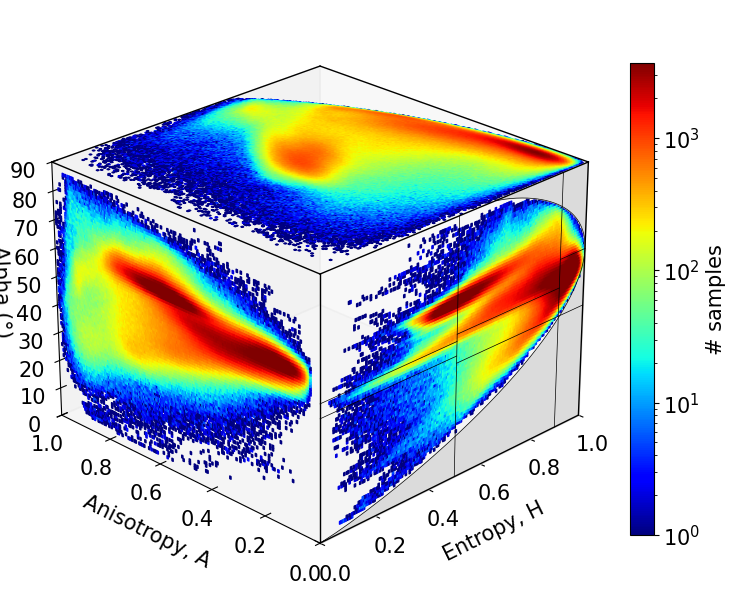

In [8]:
hFile = C3Folder + '/H_fp.tif'
aFile = C3Folder + '/anisotropy_fp.tif'
alphaFile = C3Folder + '/alpha_fp.tif'

pst.plot_h_a_alpha_fp(hFile,aFile,alphaFile,cmap='jet',               
                   norm='log',
                   # ppath = '',# give a name.png to save the plot as png 
                  zone_lines=True,
                  # zone_ids=False,
                   )

#### 4.2. Generate Yamaguchi 4-Component Decomposition parameters

In [9]:
"""
The following function generates the Yamaguchi 4-Component Decomposition parameters: 
        Yam4co_odd, Yam4co_dbl, Yam4co_vol and Yam4co_hlx in geotif format

input C3/T3 folder path, window_size is optional  

"""

pst.yamaguchi_4c(C3Folder,win=3) 

Progress: 100%|█████████████████████████████████████████████████████████████| 24/24 [00:01<00:00, 17.43block/s]


Saved file ../data/ALOS2_QP/rlee_3x3/C3/Yam4co_odd.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/Yam4co_dbl.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/Yam4co_vol.tif
Saved file ../data/ALOS2_QP/rlee_3x3/C3/Yam4co_hlx.tif
Execution time for yamaguchi_4c: 1.00 seconds


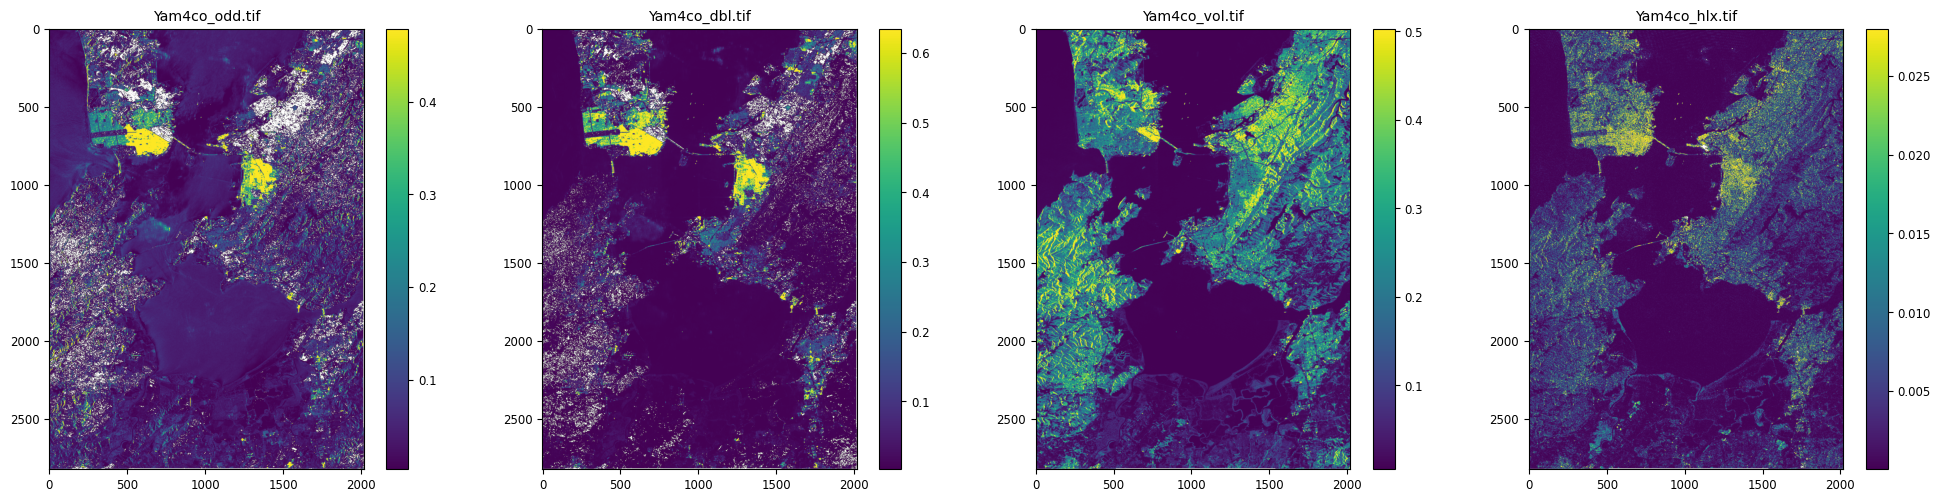

In [10]:
### Plotting
plot_images(os.path.join(C3Folder,'Yam4co_odd.tif'),
            os.path.join(C3Folder,'Yam4co_dbl.tif'),
            os.path.join(C3Folder,'Yam4co_vol.tif'),
            os.path.join(C3Folder,'Yam4co_hlx.tif'),
           )

#### Create False colour RGB from decomposed powers

RGB image saved as ../data/ALOS2_QP/rlee_3x3/C3/RGB.png
Execution time for rgb: 3.00 seconds


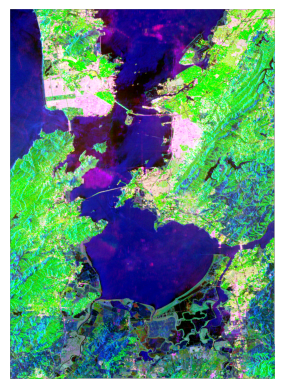

In [11]:
blue = os.path.join(C3Folder,'Yam4co_odd.tif')
red = os.path.join(C3Folder,'Yam4co_dbl.tif')
green = os.path.join(C3Folder,'Yam4co_vol.tif')

pst.rgb(red,green,blue)
